In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from rdkit.Chem import PandasTools

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
file_path = 'new_DE_data.xlsx'
df= pd.read_excel(file_path)

clean_data = df.dropna(how="all", inplace=True)
PandasTools.RenderImagesInAllDataFrames(images=True)
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')
pd.set_option('display.max_rows', 10)
#df

Are Δε and Δn correlated? LEts see

No, they arent.

(-0.1, 0.5)

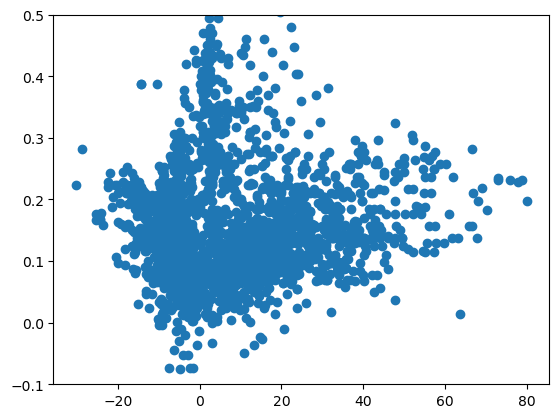

In [4]:
df["Δε"] = (
    df["Δε"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

df["Δn"] = (
    df["Δn"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

plt.scatter(df["Δε"], df["Δn"])
plt.ylim([-.1,.5])

In [6]:
df["Δε"] = (
    df["Δε"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

neg = df.loc[df["Δε"] <= 0, "Δε"]
pos = df.loc[df["Δε"] >= 0, "Δε"]

print(f"Negative Δε: N={len(neg)}, %={len(neg) / len(neg+pos):.2}, mean={neg.mean():.2f} std={neg.std():.2f}")
print(f"Positive Δε: N={len(pos)}, %={len(pos) / len(neg+pos):.2}, mean={pos.mean():.2f} std={pos.std():.2f}")


Negative Δε: N=1379, %=0.44, mean=-6.86 std=4.52
Positive Δε: N=1763, %=0.56, mean=16.18 std=14.11


In [7]:
from rdkit.Chem import Descriptors
def getMolDescriptors(mol, missingVal=None):
    ''' calculate the full list of descriptors for a molecule
    
        pass back missingVal is used if the descriptor cannot be calculated
    '''
    res = {}
    for nm,fn in Descriptors._descList:
        # some of the descriptor fucntions can throw errors if they fail, catch those here:
        try:
            val = fn(mol)
        except:
            # print the error message:
            import traceback
            traceback.print_exc()
            # and set the descriptor value to whatever missingVal is
            val = missingVal
        res[nm] = val
    return res

In [8]:
allDescrs = [getMolDescriptors(m) for m in df['ROMol']]
df_desc = pd.DataFrame(allDescrs)
df_desc["Δε"] = df["Δε"]

In [ ]:
print(f" Average molecular weight is {np.mean(df_desc['MolWt']}")
print(f" Std. Dev. of molecualr weight is {np.std(df_desc['MolWt']}")

In [ ]:
# which descriptors do we care about? A lot of them aren't really relevent, but stuff around [120] looks pertinent. 
# I think fraction that is saturated hydrocarbon matters, plus molecular weight
df_desc.columns[120::]

In [ ]:
fix, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(8, 6))

plt.subplot(2, 2, 1)
pannel_one(df_desc)

plt.subplot(2, 2, 2)
pannel_two(df_desc)

plt.subplot(2,2,3)
pannel_three(df_desc)

plt.subplot(2,2,4)
pannel_four()

plt.tight_layout()

In [ ]:
def pannel_one(df_desc):
    
    counts, bins, patches = plt.hist(
        df_desc["Δε"],
        bins=25,
        alpha=0.55,
        edgecolor='k'
    )
    
    plt.ylabel('count')
    plt.xlim([-50,100])
    plt.xlabel('Experimental Δε')
    
    for bin_left, bin_right, patch in zip(bins[:-1], bins[1:], patches):
        bin_center = 0.5 * (bin_left + bin_right)
        if bin_center > 0:
            patch.set_facecolor('tab:blue')
        else:
            patch.set_facecolor('tab:orange')
            
    legend_elements = [
        Patch(facecolor='tab:blue', edgecolor='k', alpha=0.55, label='Δε > 0'),
        Patch(facecolor='tab:orange', edgecolor='k', alpha=0.55, label='Δε ≤ 0'),
    ]
    
    plt.legend(handles=legend_elements, frameon=False)
    plt.subplot(2, 2, 2)
    
    plt.hist(df_desc["MolWt"],bins=50, alpha = 0.55, edgecolor='k')
    plt.ylabel('count')
    plt.xlim([0,1000])
    plt.xlabel('Mol. Wt.')


def pannel_two(df_desc):
    plt.hist(df_desc["MolWt"],bins=50, alpha = 0.55, edgecolor='k')
    plt.ylabel('count')
    plt.xlim([0,1000])
    plt.xlabel('Mol. Wt.')


In [ ]:
from scipy.stats import gaussian_kde

def pannel_three(df_desc):
    x = df_desc['FractionCSP3'].to_numpy()
    y = df["Δε"].to_numpy()
    
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    plt.scatter(x, y, s=32, alpha=0.33, edgecolors='none')
    
    # As elsewhere, use the kernel density to help us with the super dense data.
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    
    xi, yi = np.mgrid[
        x.min():x.max():200j,
        y.min():y.max():200j
    ]
    
    zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
    
    plt.contour(xi, yi, zi, levels=10, cmap = 'plasma', linewidths=2)
    
    plt.xlabel("Fraction $C_{SP3}$")
    plt.ylabel("Δε (exp)")

    plt.tight_layout()

In [ ]:
import pickle

with open("fingerprint_dict_20260125_v1.pkl", "rb") as f:
    fps = pickle.load(f)

In [ ]:
fps_mordred = fps['mordred_fingerprint']

In [ ]:
import numpy as np
import umap
import matplotlib.pyplot as plt

y = df["Δε"].to_numpy()
fps_mordred = fps['mordred_fingerprint']

mask_y = np.isfinite(y) # ignore any weird data (e.g. has a comma in it, wrong column stuff like that)

X = fps_mordred[mask_y]
y = y[mask_y]

col_mask = np.all(np.isfinite(X), axis=0) # bin off weird data in the fingerprints
X = X[:, col_mask]

row_mask = np.all(np.isfinite(X), axis=1) # chuck out rows with nans 
X = X[row_mask]
y = y[row_mask]

print(f"UMAP input shape: {X.shape}")

emb = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    random_state=0
).fit_transform(X)

plt.scatter(
    emb[:, 0], emb[:, 1],
    c=y,
    cmap='viridis',
    s=8,
    alpha=0.7
)
plt.colorbar(label='Δε')
plt.title("UMAP (Mordred descriptors)")
plt.tight_layout()


In [ ]:
def pannel_four():
    # note, relies on globals from above - bad practice.
    sign = np.sign(y)
    mag = np.abs(y)
    
    plt.scatter(
        emb[:,0], emb[:,1],
        c=sign,
        cmap='bwr',
        s=32,
        alpha = 0.33
    )
    
    from matplotlib.patches import Patch
    
    legend_elements = [
        Patch(facecolor=plt.cm.bwr(1.0), label='+Δε'),
        Patch(facecolor=plt.cm.bwr(0.0), label='−Δε'),
    ]
    
    plt.legend(handles=legend_elements, frameon=False)
    plt.xlabel("UMAP dimension 1")
    plt.ylabel("UMAP dimension 2")
